In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
data = pd.read_csv("shopify_sales.csv")
data.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


# Descripción del Dataset

In [11]:
# Cantidad filas y columnas
data.shape # Información sobre la cantidad de filas y columnas del dataset.

(60000, 17)

In [12]:
data.info() # Muestra información del dataset, como el tipo de datos de cada columna y la cantidad de valores nulos.

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  str    
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  str    
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  str    
 9   traffic_source    60000 non-null  str    
 10  payment_method    60000 non-null  str    
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  int64  
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float64
dtypes: f

In [13]:
data.sample(10) # Trae 10 filas aleatorias del dataset

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
40984,40985,2025-04-01,42346,3671,Footwear,760.03,0,1,Canada,Organic,Apple Pay,6.86,2.8,0,760.03,760.03,753.17
45437,45438,2024-11-28,13512,5118,Sports,746.20,15,4,Australia,Email,PayPal,7.13,4.7,1,634.27,2537.08,2529.95
17365,17366,2024-04-03,49811,1206,Footwear,130.15,15,3,Australia,Email,Apple Pay,14.75,3.2,0,110.63,331.89,317.14
41801,41802,2023-05-11,46470,6691,Home Decor,498.44,0,3,Australia,Direct,Apple Pay,14.84,4.7,0,498.44,1495.32,1480.48
1134,1135,2023-01-28,48620,5441,Beauty,101.77,20,3,Australia,Organic,PayPal,20.62,2.4,0,81.42,244.26,223.64
10630,10631,2025-01-08,43070,7838,Electronics,56.07,0,5,UAE,Organic,Apple Pay,4.96,2.0,0,56.07,280.35,275.39
23409,23410,2024-05-02,18327,4027,Beauty,775.14,5,5,Canada,Email,PayPal,19.58,3.7,0,736.38,3681.90,3662.32
8635,8636,2024-09-21,46660,6119,Sports,575.65,20,1,Canada,Social Media,Debit Card,22.95,3.3,1,460.52,460.52,437.57
53457,53458,2023-10-03,16535,2263,Sports,563.14,40,3,USA,Social Media,Debit Card,16.59,3.4,0,337.88,1013.64,997.05
42863,42864,2025-01-09,31912,2228,Beauty,286.62,30,3,Australia,Organic,Credit Card,21.21,3.8,0,200.63,601.89,580.68


**Granularidad:** Cada fila representa una venta diferente

In [14]:
data.set_index('order_id', inplace=True) # Establece la columna 'order_id' como índice del DataFrame. El nombre de cada fil es el número de la venta

In [15]:
data.head() 

,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
order_id,,,,,,,,,,,,,,,,
1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


In [16]:
columns_date = ['order_date']
columns_categorical = ['customer_id', 'product_id', 'product_category', 'customer_country', 'traffic_source', 'payment_method',
'is_returned']
columns_numerical = [col for col in data.columns if col not in columns_date + columns_categorical]
len(columns_date) + len(columns_categorical) + len(columns_numerical) == data.shape[1] # Verifica que la suma de las columnas sea igual a la cantidad de columnas del dataset

True

In [17]:
data.index.value_counts() # Muestra la cantidad de veces que se repite cada valor en la columna 'order_id'.

order_id
1        1
2        1
3        1
4        1
5        1
        ..
59996    1
59997    1
59998    1
59999    1
60000    1
Name: count, Length: 60000, dtype: int64

In [18]:
for col_date in columns_date:
    data[col_date] = pd.to_datetime(data[col_date]) # Convierte las columnas de tipo fecha a tipo datetime

for col_categorical in columns_categorical:
    data[col_categorical] = data[col_categorical].astype('category') # Convierte las columnas categóricas a tipo category

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 1 to 60000
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_date        60000 non-null  datetime64[us]
 1   customer_id       60000 non-null  category      
 2   product_id        60000 non-null  category      
 3   product_category  60000 non-null  category      
 4   product_price     60000 non-null  float64       
 5   discount_percent  60000 non-null  int64         
 6   quantity          60000 non-null  int64         
 7   customer_country  60000 non-null  category      
 8   traffic_source    60000 non-null  category      
 9   payment_method    60000 non-null  category      
 10  shipping_cost     60000 non-null  float64       
 11  rating            60000 non-null  float64       
 12  is_returned       60000 non-null  category      
 13  discounted_price  60000 non-null  float64       
 14  revenue           60000 non-null 

In [19]:
data.dtypes

order_date          datetime64[us]
customer_id               category
product_id                category
product_category          category
product_price              float64
discount_percent             int64
quantity                     int64
customer_country          category
traffic_source            category
payment_method            category
shipping_cost              float64
rating                     float64
is_returned               category
discounted_price           float64
revenue                    float64
profit                     float64
dtype: object

In [20]:
data.order_date.dt.month

order_id
1         4
2         3
3         5
4         9
5         4
         ..
59996     4
59997     9
59998    11
59999     9
60000     6
Name: order_date, Length: 60000, dtype: int32

In [21]:
data.order_date.dt.day_of_week

order_id
1        3
2        0
3        5
4        3
5        0
        ..
59996    1
59997    6
59998    2
59999    6
60000    4
Name: order_date, Length: 60000, dtype: int32

In [22]:
data.order_date.dt.day_of_year

order_id
1        103
2         71
3        130
4        271
5        107
        ... 
59996    105
59997    259
59998    318
59999    253
60000    164
Name: order_date, Length: 60000, dtype: int32

# Análisis Univariante

## Categórico


ANÁLISIS DE: CUSTOMER_ID

Cantidad de categorías: 31154

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,21784,8,0.01
1,37140,8,0.01
2,39920,8,0.01
3,11823,7,0.01
4,12775,7,0.01
...,...,...,...
31149,49993,1,0.00
31150,49995,1,0.00
31151,49997,1,0.00
31152,49998,1,0.00



Nota: customer_id tiene 31154 categorías (≥10), no se generó gráfico.

ANÁLISIS DE: PRODUCT_ID

Cantidad de categorías: 6998

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,3021,20,0.03
1,2932,19,0.03
2,3075,19,0.03
3,3107,19,0.03
4,6051,19,0.03
...,...,...,...
6993,7853,2,0.00
6994,5019,1,0.00
6995,5162,1,0.00
6996,6023,1,0.00



Nota: product_id tiene 6998 categorías (≥10), no se generó gráfico.

ANÁLISIS DE: PRODUCT_CATEGORY

Cantidad de categorías: 7

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Electronics,8624,14.37
1,Accessories,8617,14.36
2,Home Decor,8600,14.33
3,Fashion,8594,14.32
4,Beauty,8586,14.31
5,Sports,8522,14.20
6,Footwear,8457,14.10


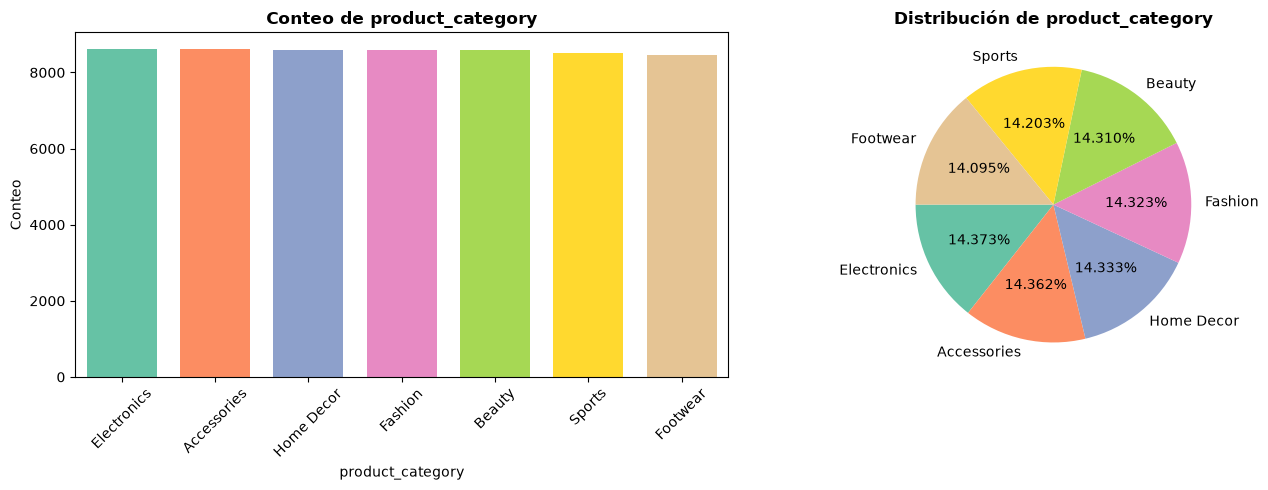


ANÁLISIS DE: CUSTOMER_COUNTRY

Cantidad de categorías: 7

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Australia,8714,14.52
1,Germany,8606,14.34
2,UAE,8599,14.33
3,Canada,8586,14.31
4,India,8554,14.26
5,UK,8472,14.12
6,USA,8469,14.12


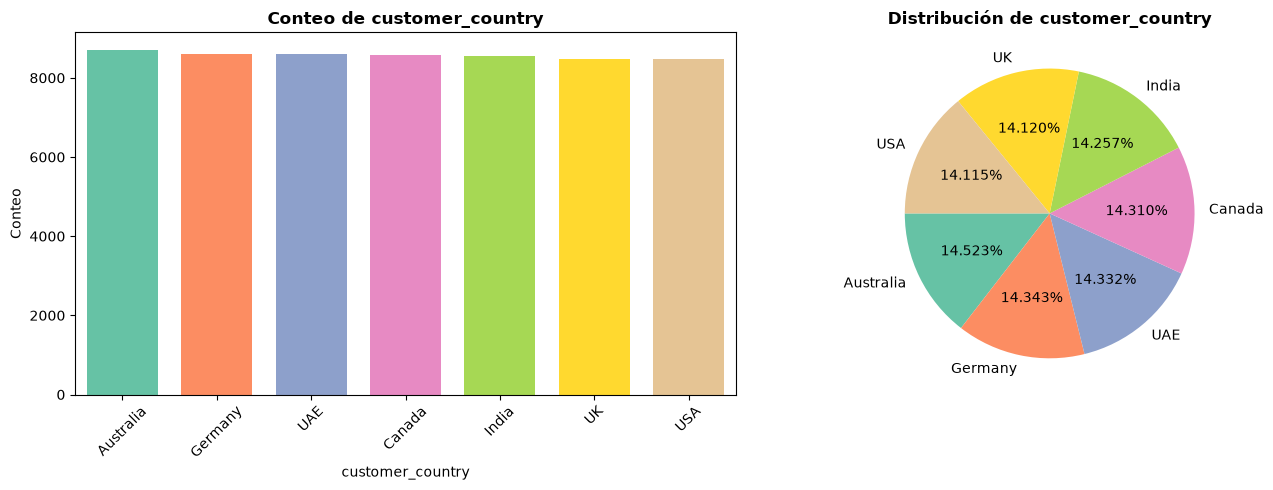


ANÁLISIS DE: TRAFFIC_SOURCE

Cantidad de categorías: 5

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Organic,12075,20.12
1,Social Media,12024,20.04
2,Paid Ads,12018,20.03
3,Direct,11961,19.93
4,Email,11922,19.87


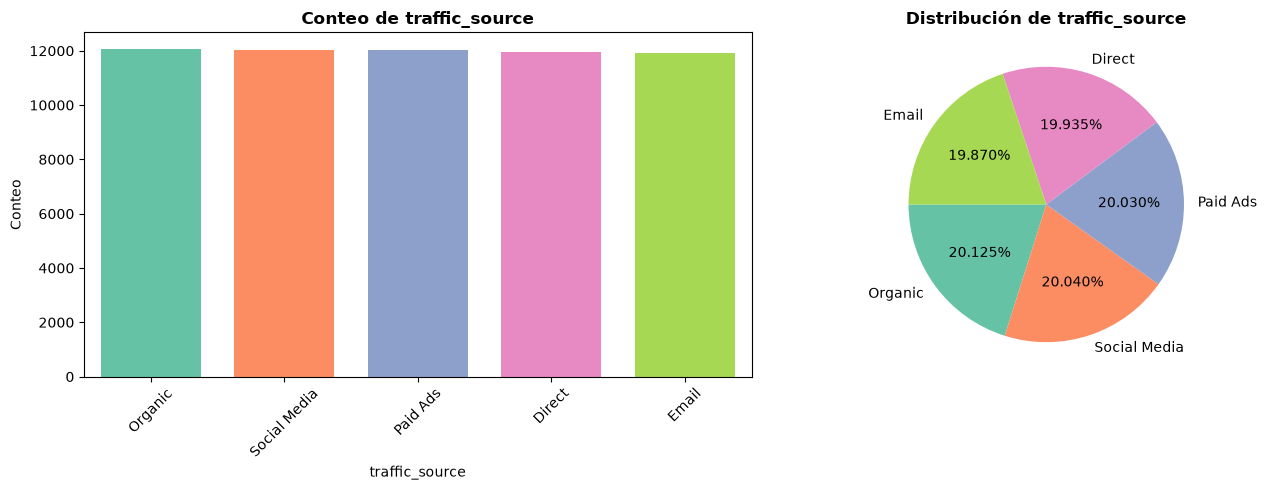


ANÁLISIS DE: PAYMENT_METHOD

Cantidad de categorías: 5

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,Apple Pay,12116,20.19
1,Cash on Delivery,12032,20.05
2,Credit Card,11998,20.00
3,Debit Card,11936,19.89
4,PayPal,11918,19.86


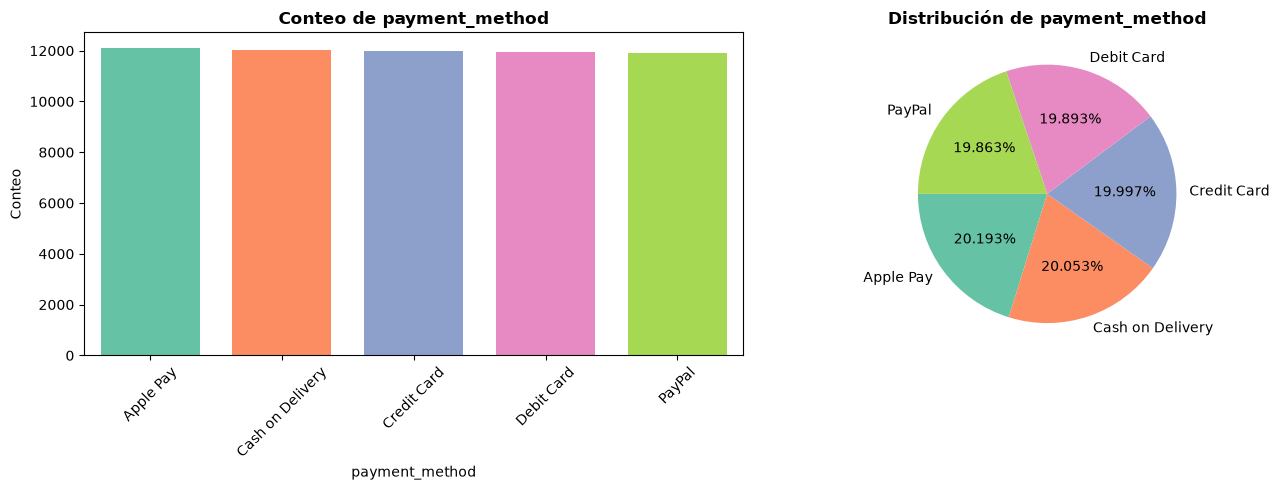


ANÁLISIS DE: IS_RETURNED

Cantidad de categorías: 2

Tabla de conteo y porcentajes:


,Categoría,Conteo,Porcentaje (%)
0,0,51113,85.19
1,1,8887,14.81


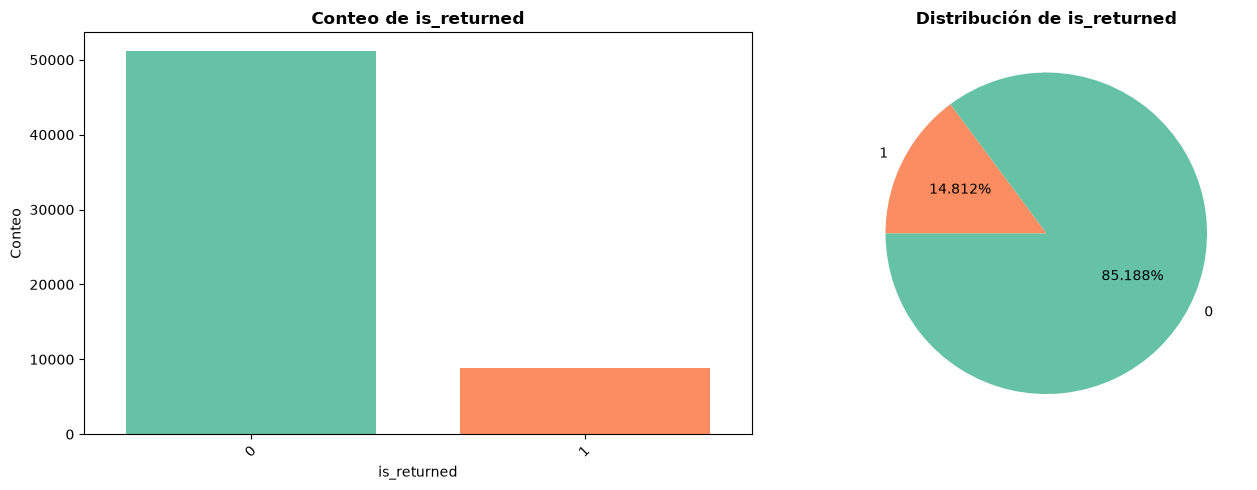

In [23]:
for col in columns_categorical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")
    
    # 1. Cantidad de categorías
    num_categories = data[col].nunique()
    print(f"\nCantidad de categorías: {num_categories}")
    
    # 2. Tabla de conteo y porcentajes
    value_counts = data[col].value_counts()
    percentage = (value_counts / len(data) * 100).round(2)
    
    table = pd.DataFrame({
        'Categoría': value_counts.index,
        'Conteo': value_counts.values,
        'Porcentaje (%)': percentage.values
    })
    table = table.reset_index(drop=True)
    print("\nTabla de conteo y porcentajes:")
    display(table)
    
    # 3. Gráfico si tiene menos de 10 categorías
    if num_categories < 10:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Crear mapeo de colores consistente
        colors_array = plt.cm.Set2(range(num_categories))
        
        # Gráfico de barras a la izquierda
        sns.countplot(data=data, x=col, ax=axes[0], 
                      order=data[col].value_counts().index, legend=False, width=0.75)
        
        # Aplicar colores manualmente a las barras para que coincidan con el pie chart
        for i, patch in enumerate(axes[0].patches):
            patch.set_facecolor(colors_array[i])
        
        axes[0].set_title(f'Conteo de {col}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel(col, fontsize=10)
        axes[0].set_ylabel('Conteo', fontsize=10)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Gráfico de torta a la derecha
        axes[1].pie(value_counts.values, labels=value_counts.index, autopct='%1.3f%%', 
                    startangle=180, colors=colors_array)
        axes[1].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nNota: {col} tiene {num_categories} categorías (≥10), no se generó gráfico.")

## Numérico


ANÁLISIS DE: PRODUCT_PRICE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
product_price,60000.0,403.427068,230.045257,5.01,203.16,403.855,603.135,799.99


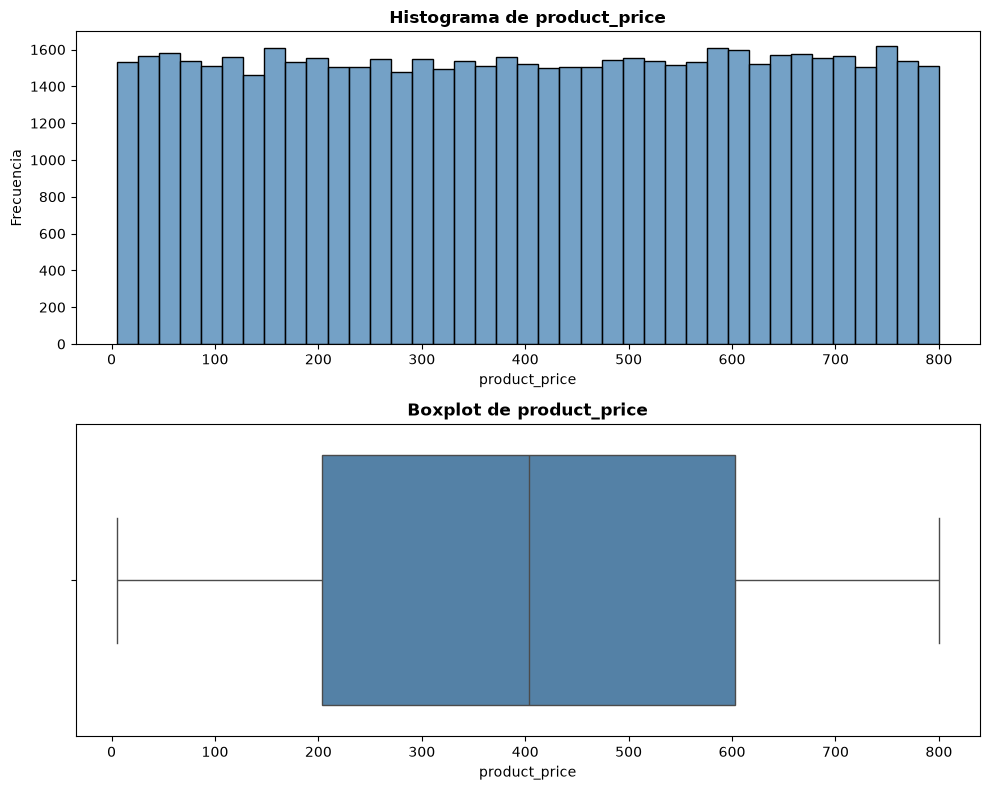


ANÁLISIS DE: DISCOUNT_PERCENT

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
discount_percent,60000.0,18.1515,12.527663,0.0,5.0,20.0,30.0,40.0


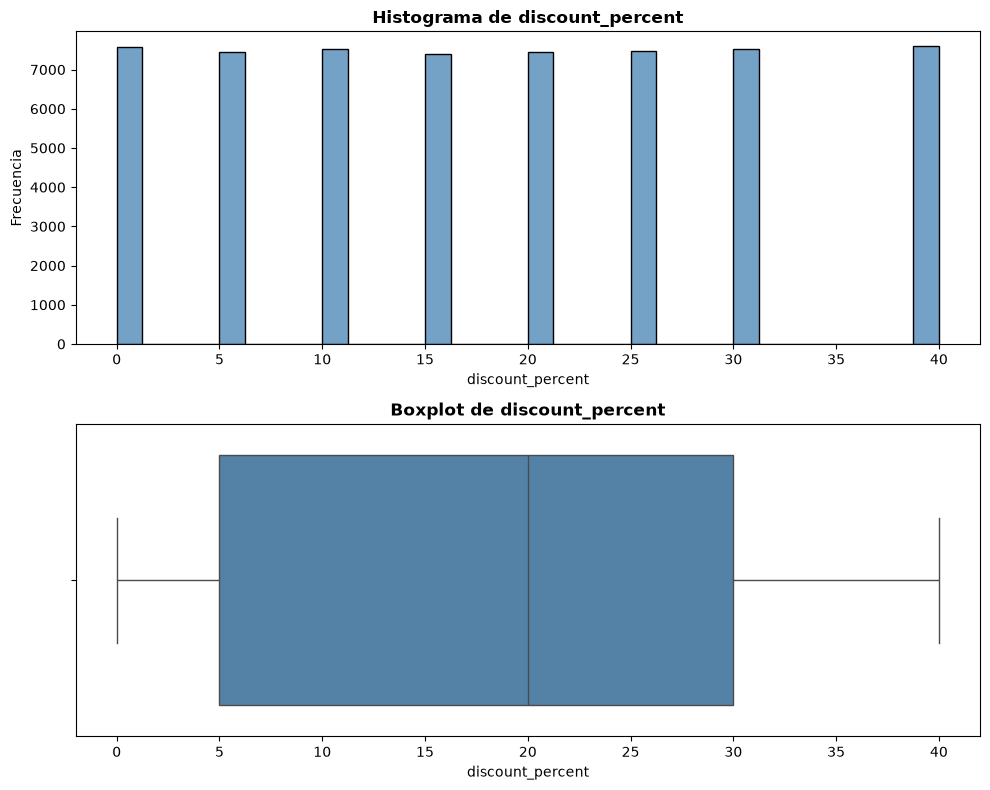


ANÁLISIS DE: QUANTITY

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
quantity,60000.0,3.009567,1.414794,1.0,2.0,3.0,4.0,5.0


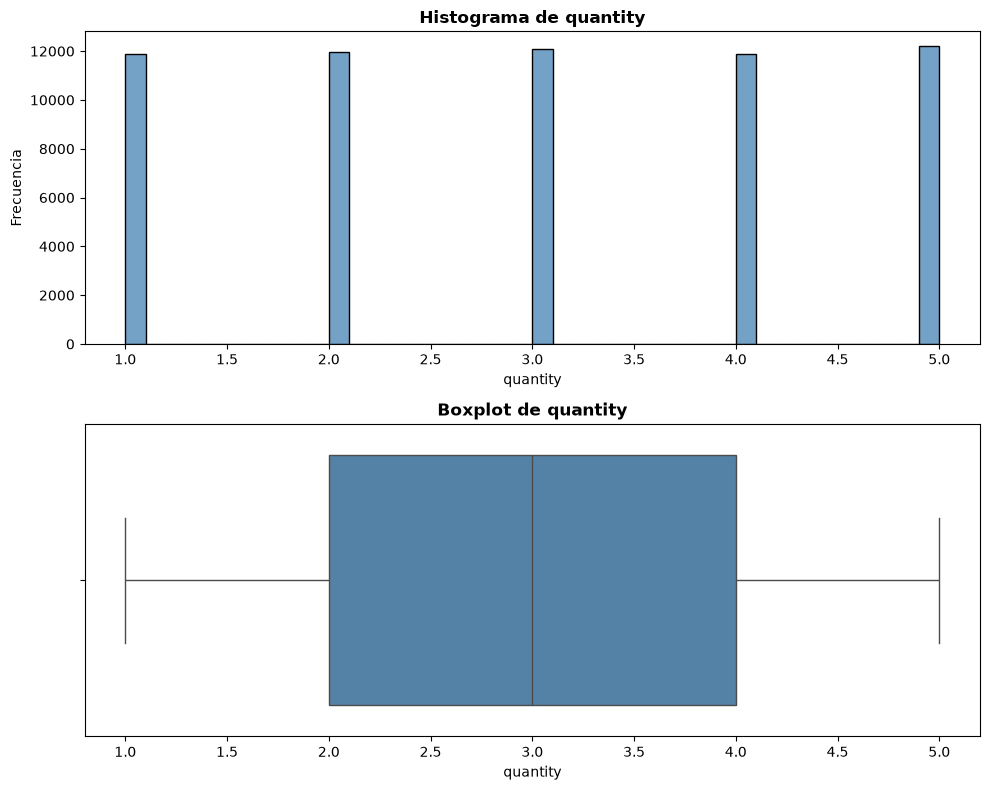


ANÁLISIS DE: SHIPPING_COST

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
shipping_cost,60000.0,13.521758,6.627934,2.0,7.76,13.58,19.23,25.0


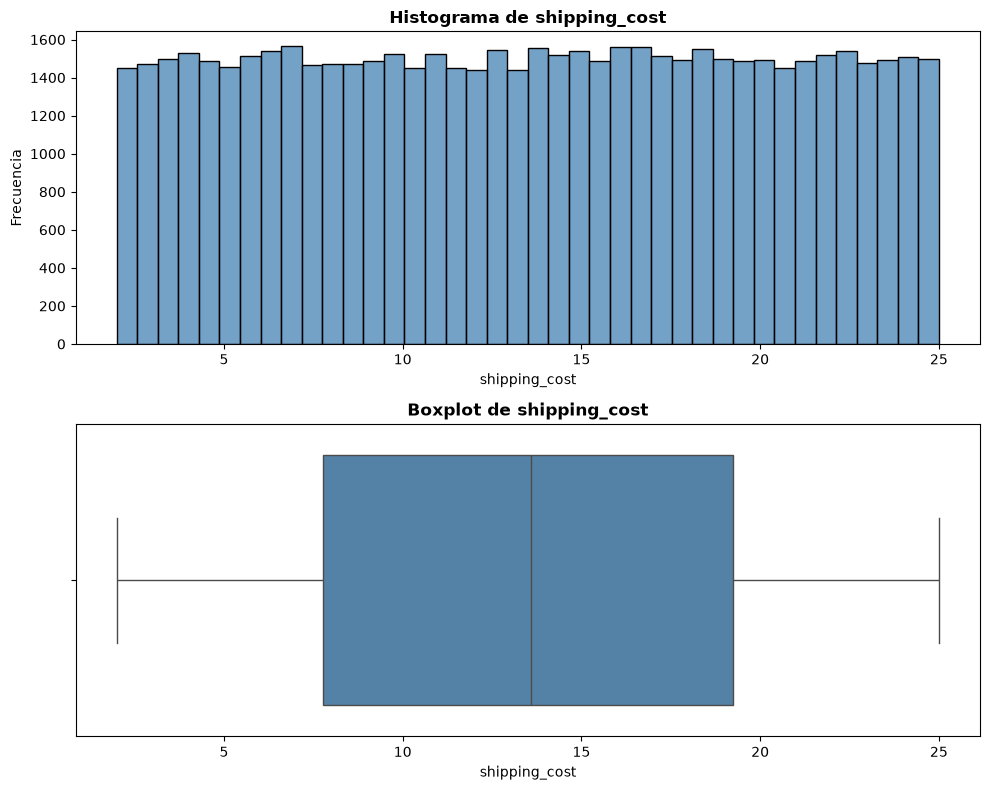


ANÁLISIS DE: RATING

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
rating,60000.0,3.00244,1.152265,1.0,2.0,3.0,4.0,5.0


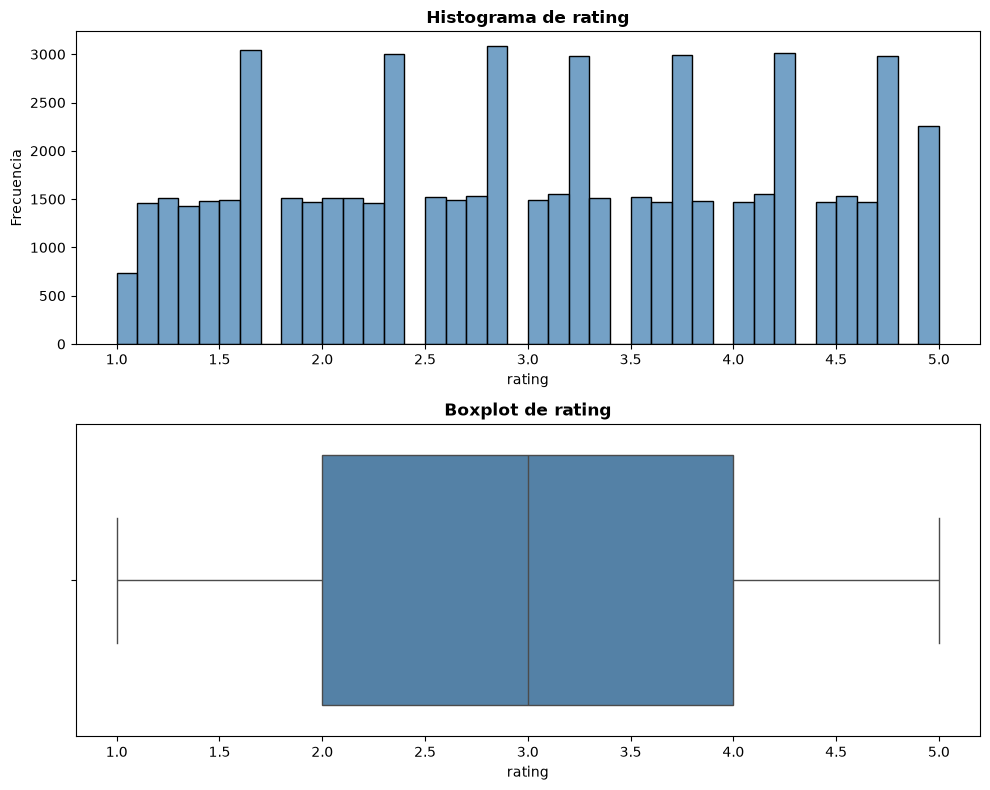


ANÁLISIS DE: DISCOUNTED_PRICE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
discounted_price,60000.0,330.220212,197.114822,3.08,161.9575,322.56,482.2425,799.9


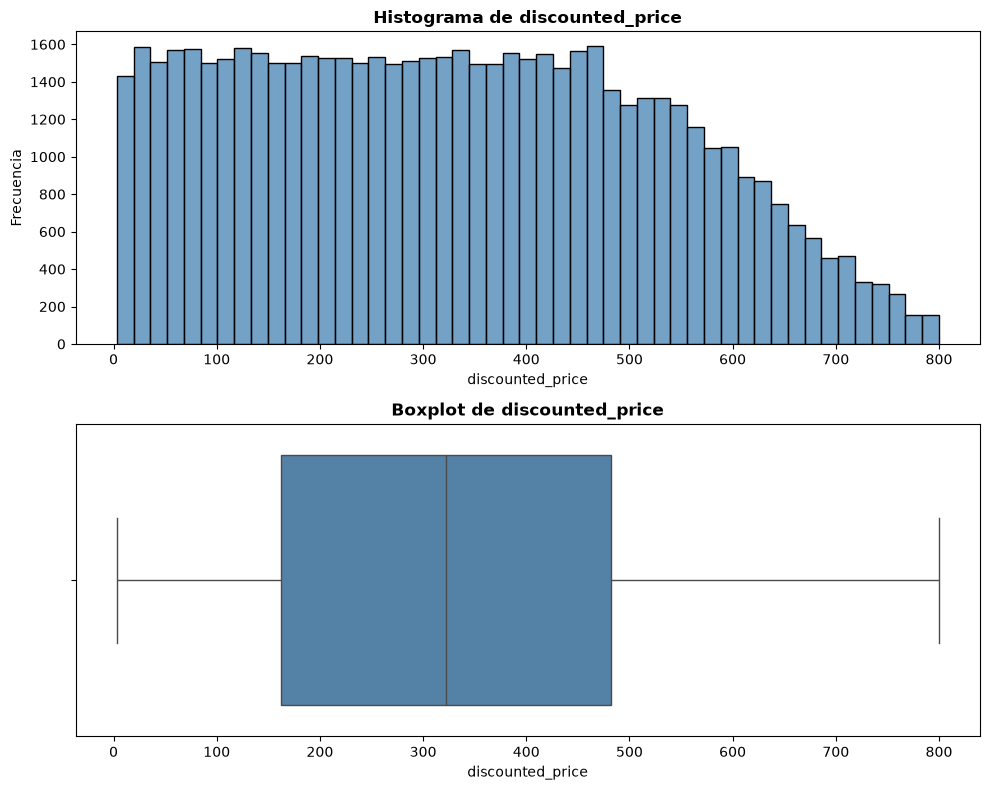


ANÁLISIS DE: REVENUE

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
revenue,60000.0,994.098926,806.445785,3.08,355.62,760.47,1462.45,3999.5


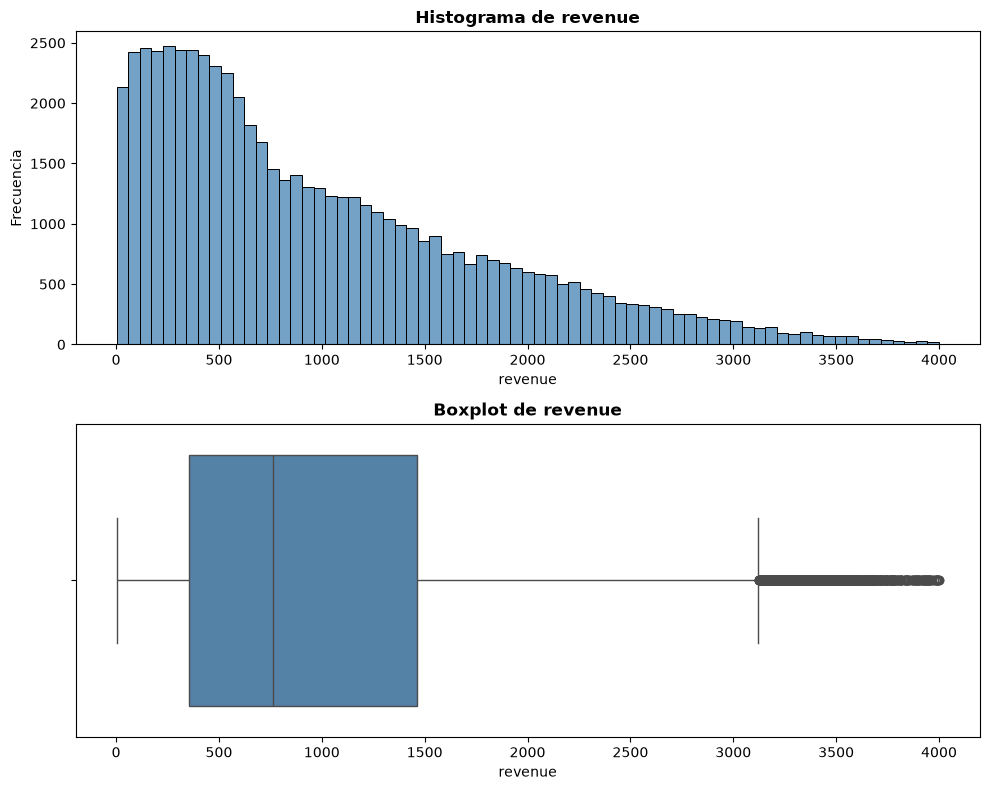


ANÁLISIS DE: PROFIT

Estadística descriptiva:


,count,mean,std,min,25%,50%,75%,max
profit,60000.0,980.577168,806.508355,-20.49,341.925,747.275,1449.8075,3989.95


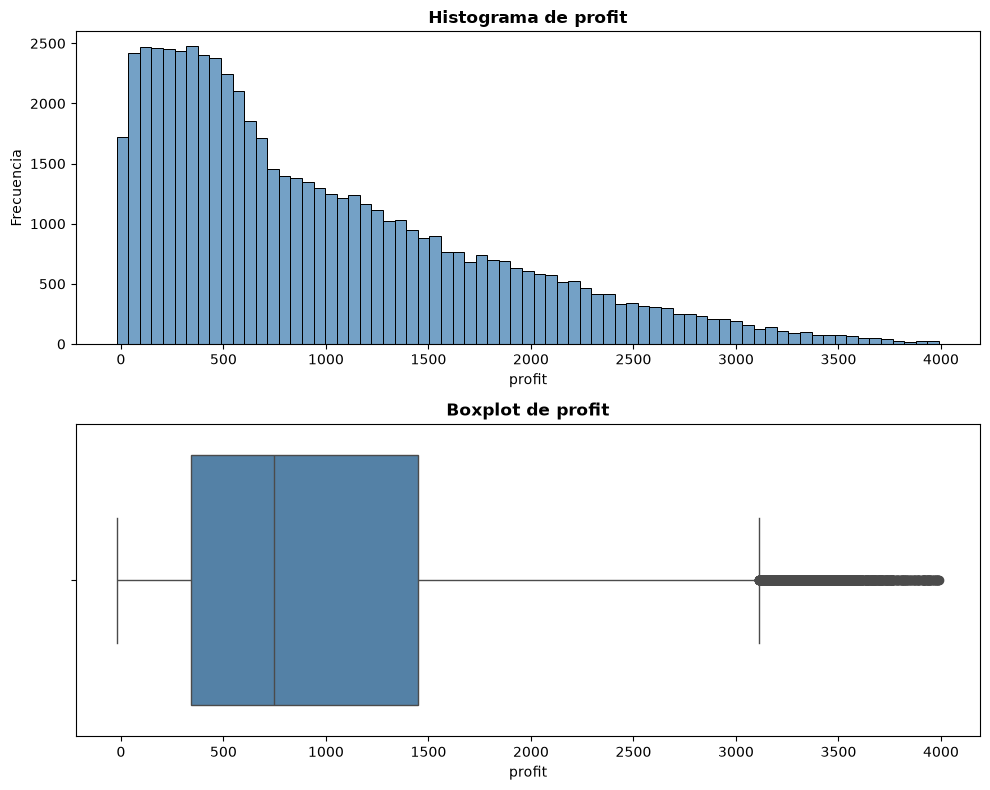

In [24]:
for col in columns_numerical:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")
    
    # Tabla de estadística descriptiva
    stats = data[col].describe().to_frame().T
    print("\nEstadística descriptiva:")
    display(stats)
    
    # Subplots: histograma arriba, boxplot abajo
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    sns.histplot(data=data, x=col, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Histograma de {col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col, fontsize=10)
    axes[0].set_ylabel('Frecuencia', fontsize=10)
    
    sns.boxplot(data=data, x=col, ax=axes[1], color='steelblue')
    axes[1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=10)
    
    plt.tight_layout()
    plt.show()

## Temporal


ANÁLISIS DE: ORDER_DATE

Fecha mínima: 2023-01-01 00:00:00
Fecha máxima: 2025-06-18 00:00:00

Fecha con más ventas: 2024-10-18 00:00:00 (92 ventas)


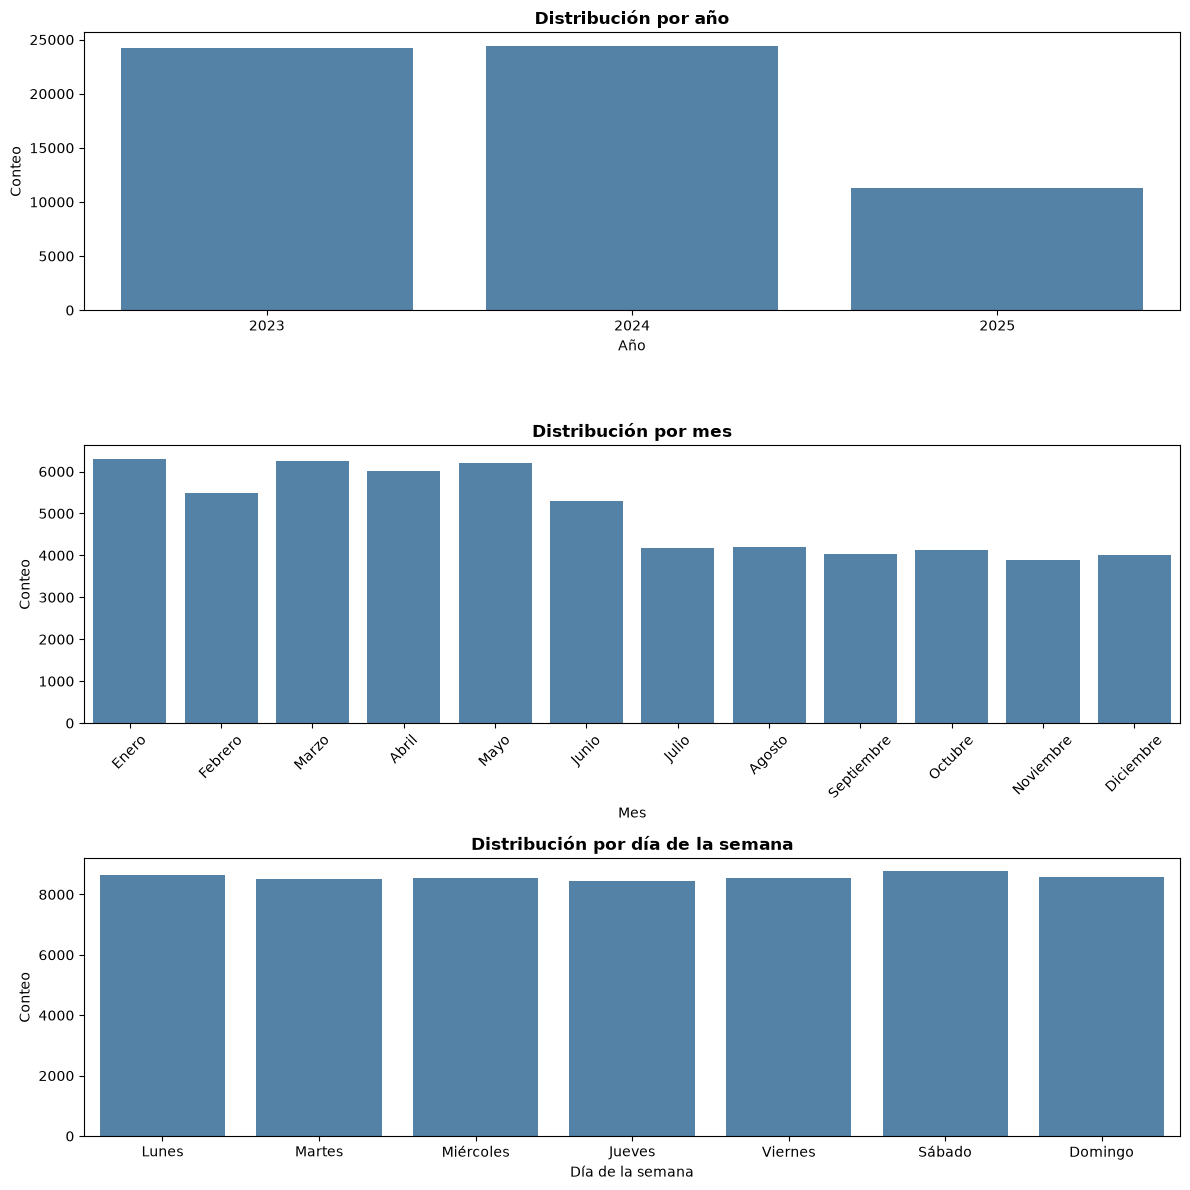

In [25]:
for col in columns_date:
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE: {col.upper()}")
    print(f"{'='*70}")
    
    # Fecha mínima y máxima
    print(f"\nFecha mínima: {data[col].min()}")
    print(f"Fecha máxima: {data[col].max()}")
    
    # Fecha con más ventas
    ventas_por_fecha = data[col].value_counts()
    print(f"\nFecha con más ventas: {ventas_por_fecha.index[0]} ({ventas_por_fecha.iloc[0]} ventas)")
    
    # Distribución por año
    fig, axes = plt.subplots(3, 1, figsize=(12, 12))
    
    sns.countplot(x=data[col].dt.year, ax=axes[0], color='steelblue')
    axes[0].set_title('Distribución por año', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Año', fontsize=10)
    axes[0].set_ylabel('Conteo', fontsize=10)
    
    # Distribución por mes
    meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
             'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
    sns.countplot(x=data[col].dt.month, ax=axes[1], color='steelblue')
    axes[1].set_title('Distribución por mes', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Mes', fontsize=10)
    axes[1].set_ylabel('Conteo', fontsize=10)
    axes[1].set_xticks(range(len(axes[1].get_xticks())))
    axes[1].set_xticklabels([meses[i] for i in range(len(axes[1].get_xticks()))], rotation=45)
    
    # Distribución por día de la semana
    dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    sns.countplot(x=data[col].dt.dayofweek, ax=axes[2], color='steelblue')
    axes[2].set_title('Distribución por día de la semana', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Día de la semana', fontsize=10)
    axes[2].set_ylabel('Conteo', fontsize=10)
    axes[2].set_xticks(range(7))
    axes[2].set_xticklabels(dias)
    
    plt.tight_layout()
    plt.show()
 

# Análisis bivariante

## Numerico

In [26]:
data[columns_numerical].corr() # Calcula la matriz de correlación entre las columnas numéricas del DataFrame.

,product_price,discount_percent,quantity,shipping_cost,rating,discounted_price,revenue,profit
product_price,1.000000,-0.000737,0.000847,-0.005456,-0.001774,0.955715,0.706162,0.706152
discount_percent,-0.000737,1.000000,-0.000939,-0.003466,-0.004019,-0.255998,-0.188741,-0.188698
quantity,0.000847,-0.000939,1.000000,-0.002925,0.003388,0.001001,0.579274,0.579254
shipping_cost,-0.005456,-0.003466,-0.002925,1.000000,-0.001226,-0.004050,-0.005331,-0.013549
rating,-0.001774,-0.004019,0.003388,-0.001226,1.000000,-0.001003,-0.000355,-0.000345
discounted_price,0.955715,-0.255998,0.001001,-0.004050,-0.001003,1.000000,0.739114,0.739090
revenue,0.706162,-0.188741,0.579274,-0.005331,-0.000355,0.739114,1.000000,0.999966
profit,0.706152,-0.188698,0.579254,-0.013549,-0.000345,0.739090,0.999966,1.000000


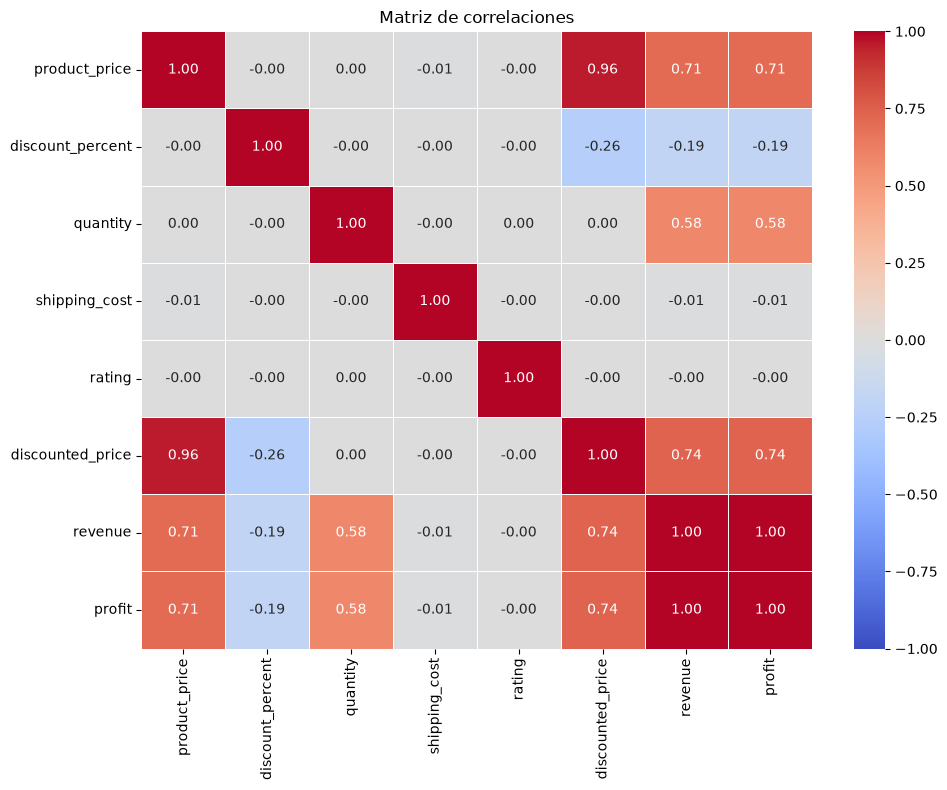

In [27]:
matriz_correlaciones = data[columns_numerical].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlaciones,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

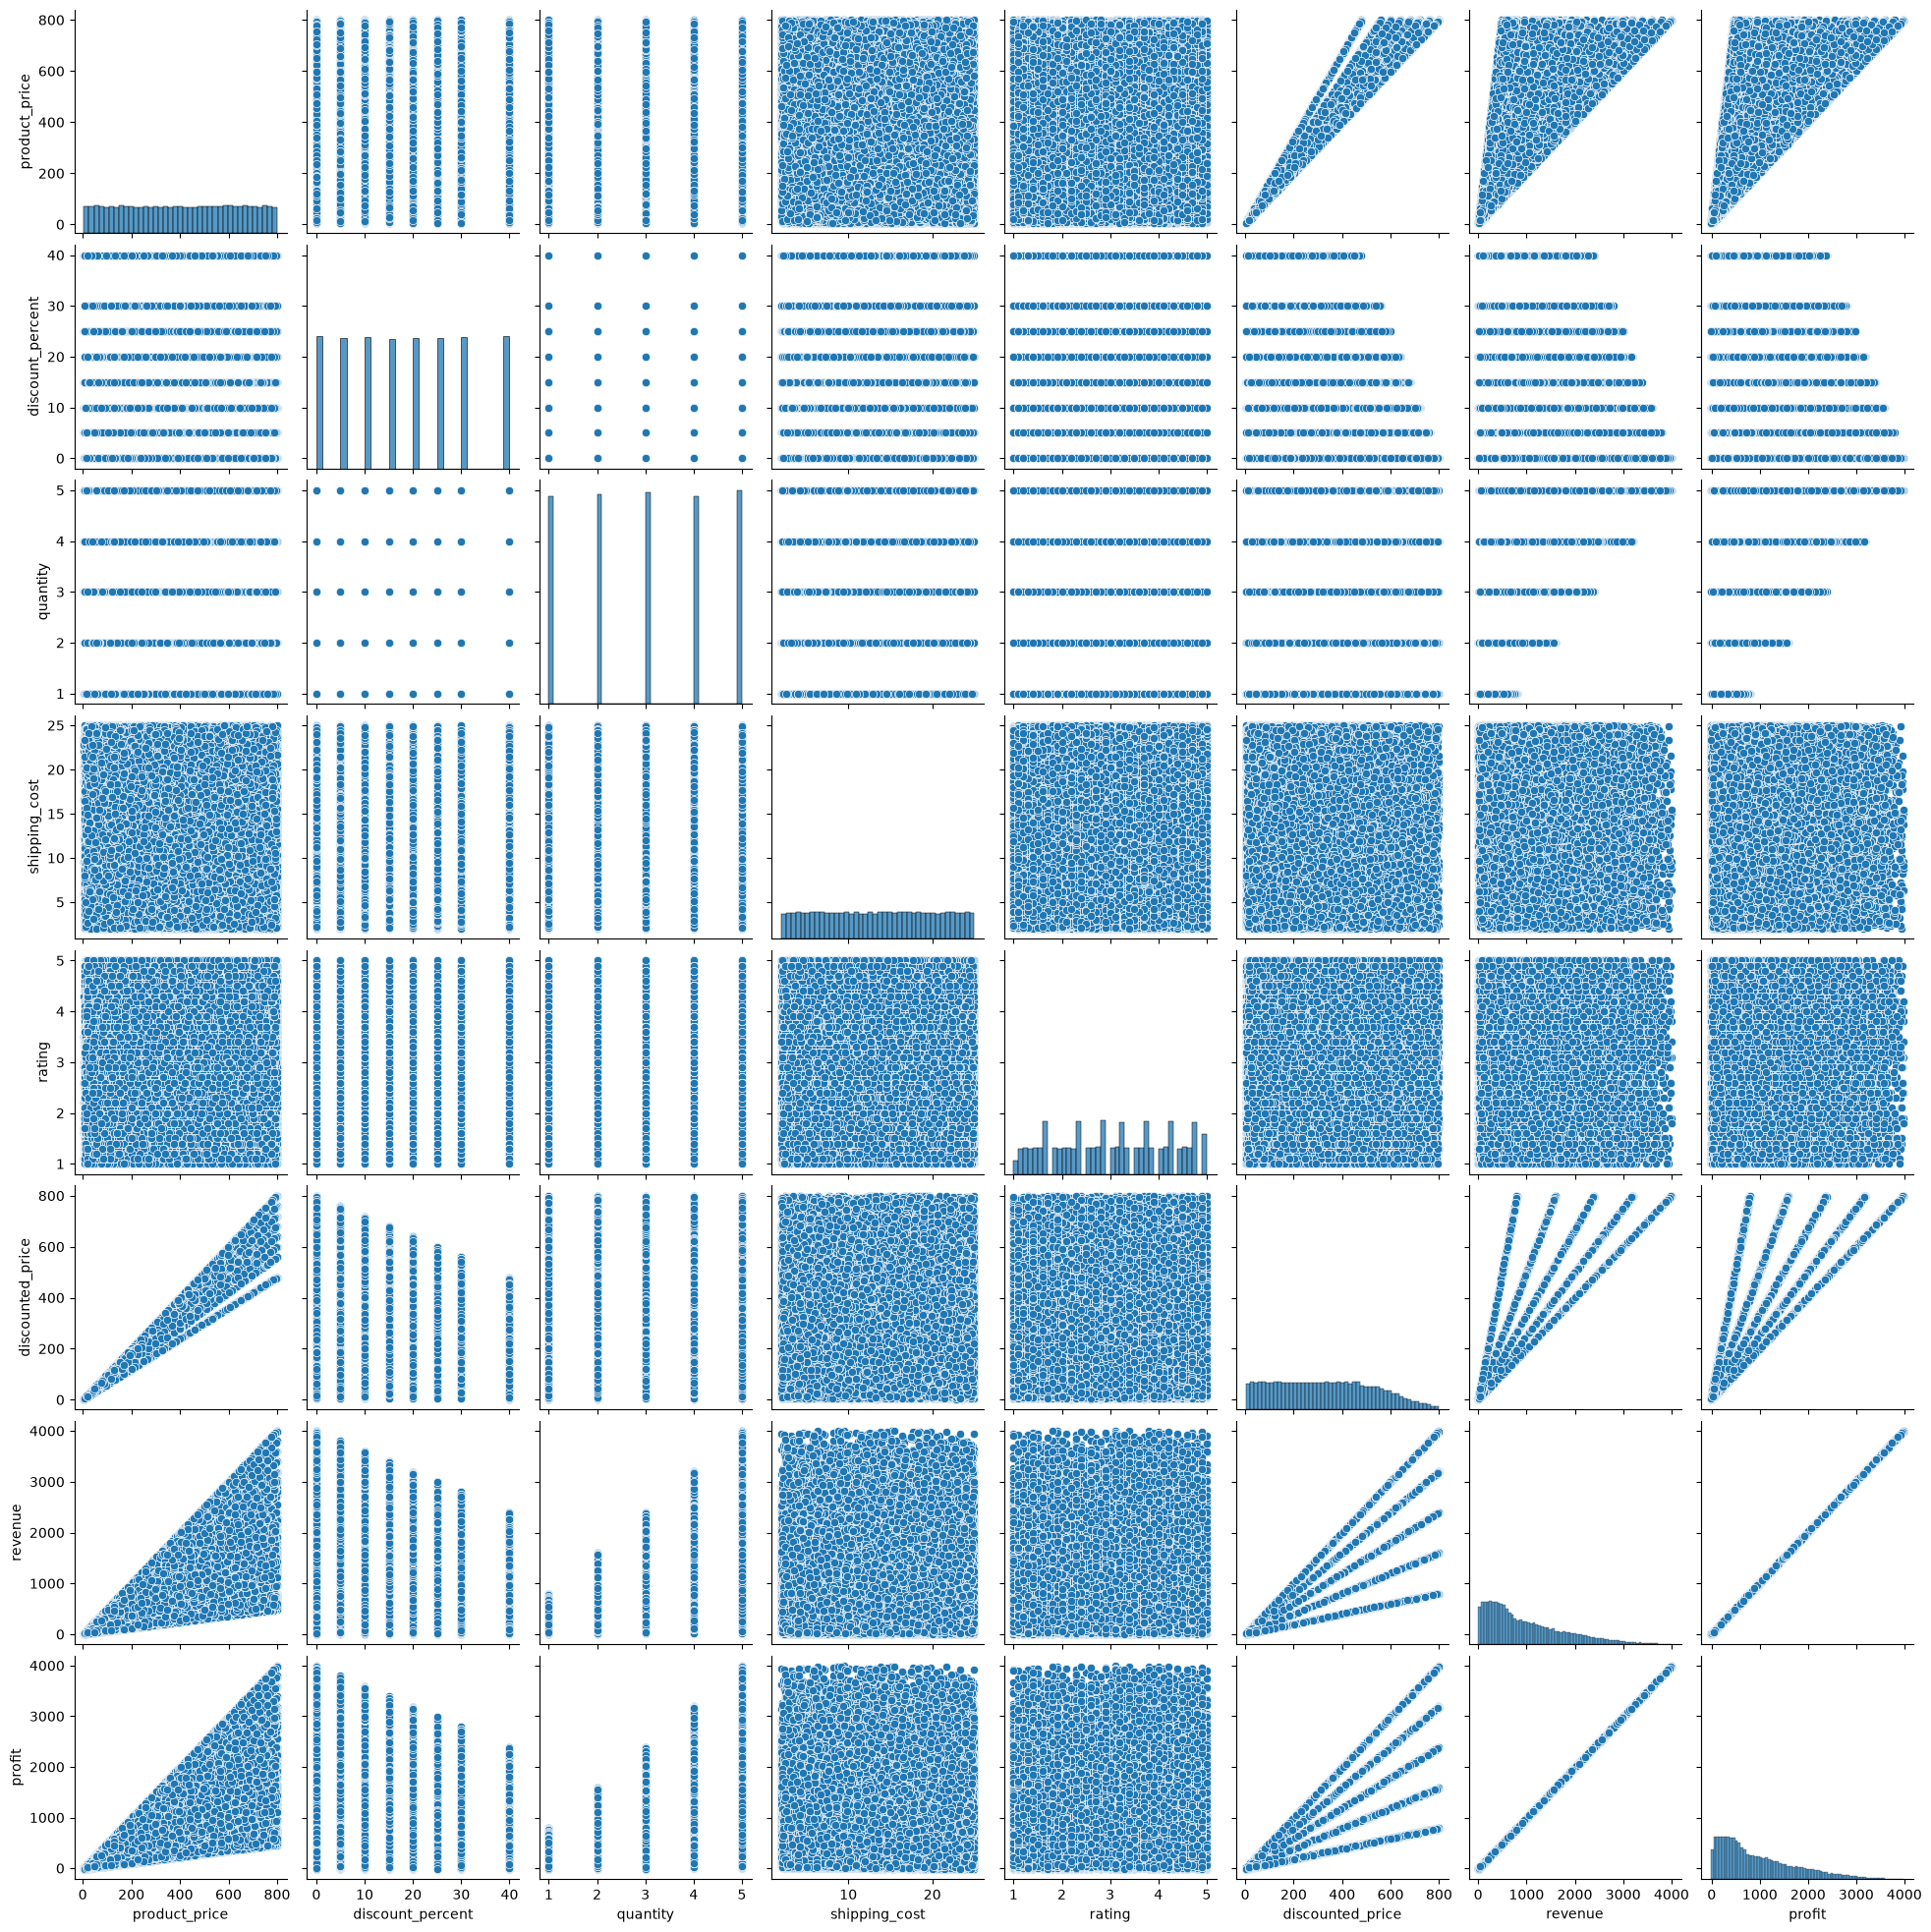

In [28]:
plt.figure(figsize=(10, 8))
sns.pairplot(data[columns_numerical])
plt.show()

## Categórico

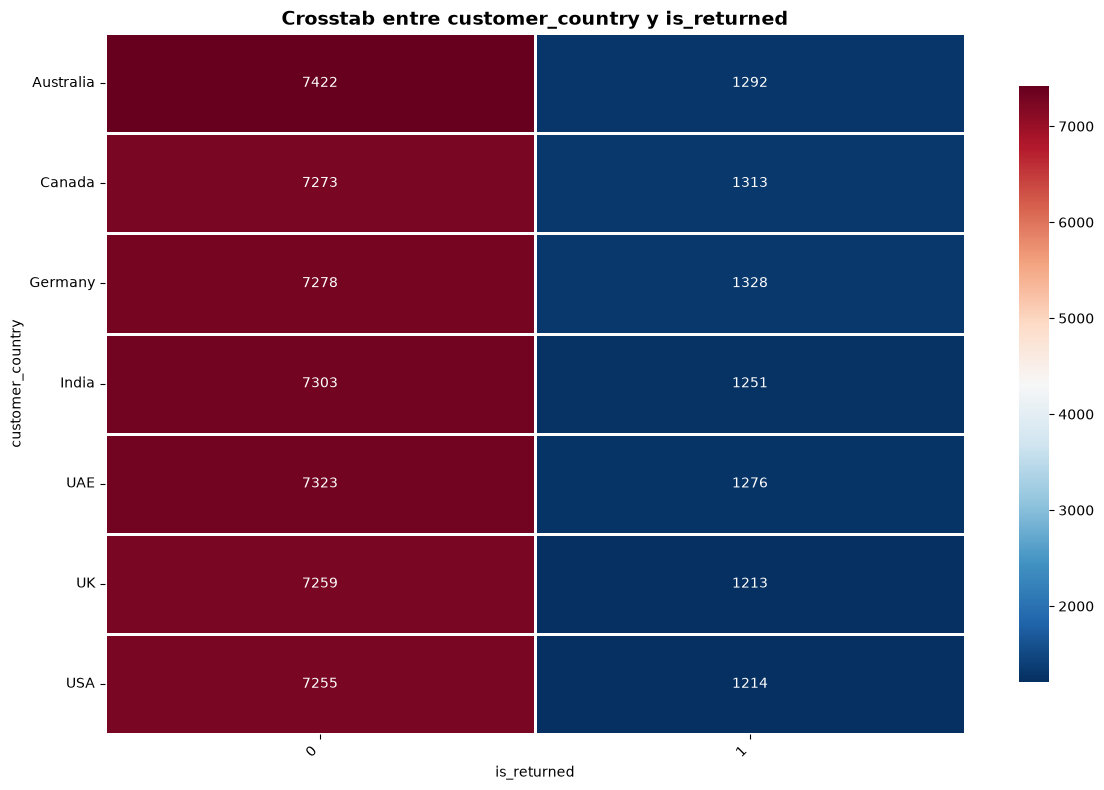

In [29]:
# Define aquí las dos columnas que quieres cruzar
columna_filas = 'customer_country'
columna_columnas = 'is_returned'

# Crosstab con conteos absolutos
crosstab = pd.crosstab(
    data[columna_filas],
    data[columna_columnas]
).astype(int)

valor_min = crosstab.values.min()
valor_max = crosstab.values.max()

plt.figure(figsize=(12, 8))
sns.heatmap(
    crosstab,
    annot=True,
    fmt='d',
    cmap='RdBu_r',
    vmin=valor_min,
    vmax=valor_max,
    linewidths=2,
    linecolor='white',
    cbar_kws={'shrink': 0.85}
)
plt.title(f'Crosstab entre {columna_filas} y {columna_columnas}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
 

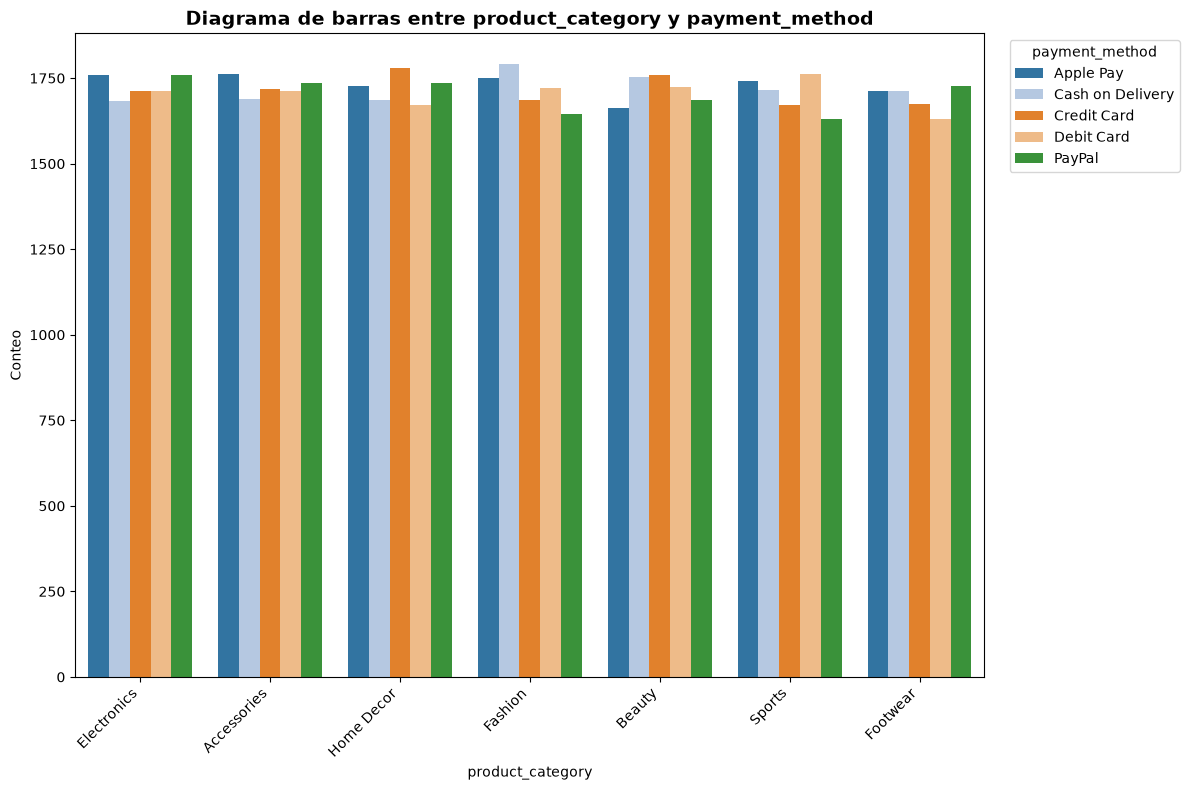

In [30]:
# Define aquí las dos columnas que quieres cruzar
columna_filas = 'product_category'
columna_columnas = 'payment_method'

plt.figure(figsize=(12, 8))
sns.countplot(
    data=data,
    x=columna_filas,
    hue=columna_columnas,
    order=data[columna_filas].value_counts().index,
    hue_order=data[columna_columnas].value_counts().index,
    palette='tab20'
)
plt.title(f'Diagrama de barras entre {columna_filas} y {columna_columnas}', fontsize=14, fontweight='bold')
plt.xlabel(columna_filas, fontsize=10)
plt.ylabel('Conteo', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.legend(title=columna_columnas, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Categórico + numérico

Variable categórica: is_returned
Variable numérica: revenue


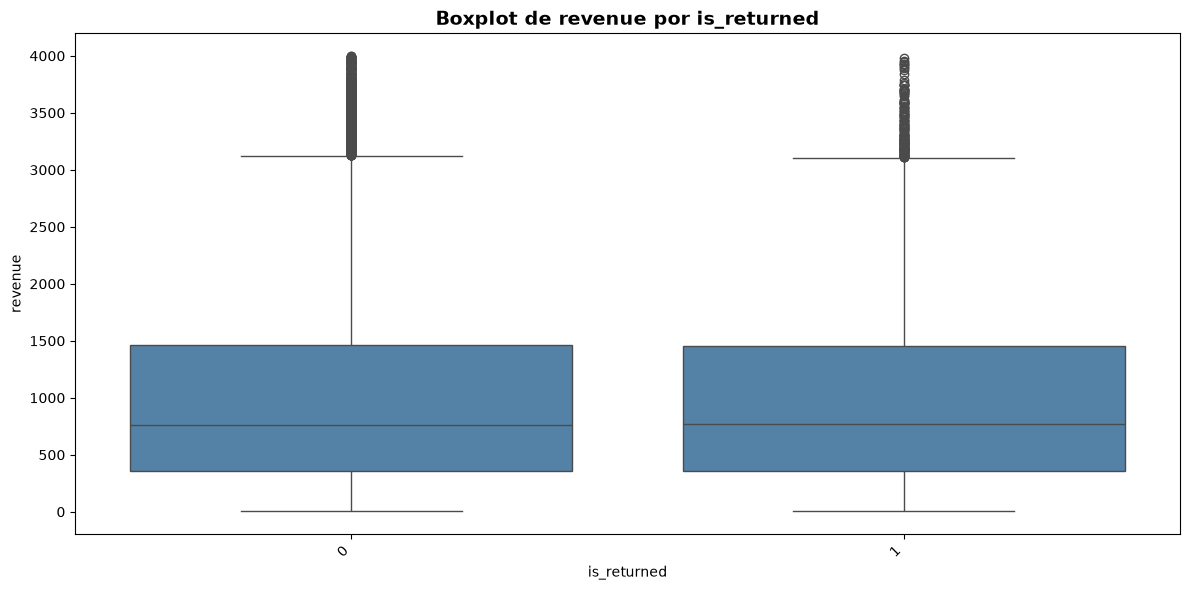

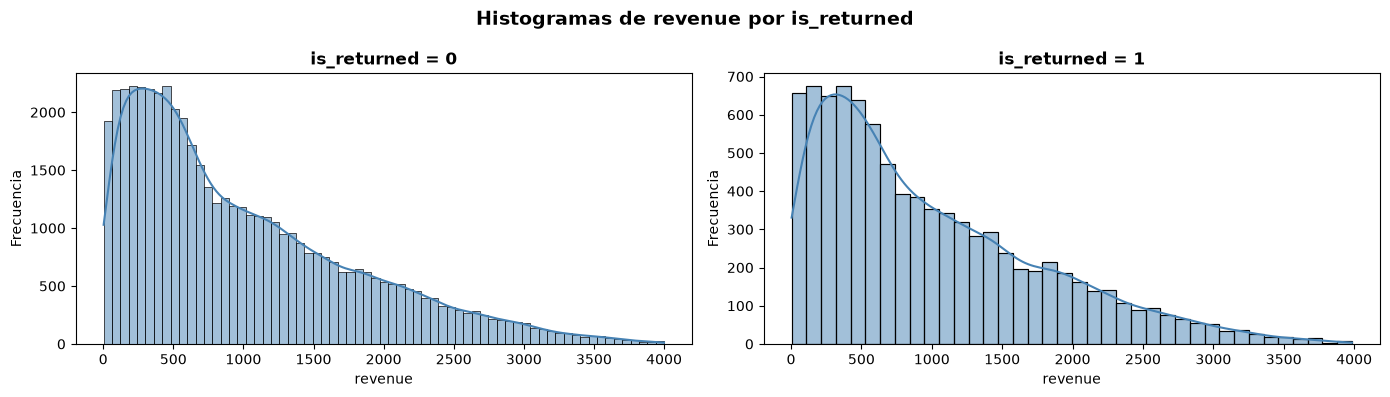

In [31]:
# Define aquí una variable categórica y una numérica
columna_categorica = 'is_returned'
columna_numerica = 'revenue'

print(f'Variable categórica: {columna_categorica}')
print(f'Variable numérica: {columna_numerica}')

# Boxplot comparativo por categoría
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=data,
    x=columna_categorica,
    y=columna_numerica,
    color='steelblue'
)
plt.title(f'Boxplot de {columna_numerica} por {columna_categorica}', fontsize=14, fontweight='bold')
plt.xlabel(columna_categorica, fontsize=10)
plt.ylabel(columna_numerica, fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Histogramas en subplots separados por categoría
categorias = data[columna_categorica].dropna().unique()
num_categorias = len(categorias)
num_columnas = 2
num_filas = (num_categorias + num_columnas - 1) // num_columnas

fig, axes = plt.subplots(num_filas, num_columnas, figsize=(14, 4 * num_filas))
axes = axes.flatten() if num_categorias > 1 else [axes]

for i, categoria in enumerate(categorias):
    subset = data[data[columna_categorica] == categoria]
    sns.histplot(
        data=subset,
        x=columna_numerica,
        kde=True,
        color='steelblue',
        ax=axes[i]
    )
    axes[i].set_title(f'{columna_categorica} = {categoria}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(columna_numerica, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)

for j in range(num_categorias, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Histogramas de {columna_numerica} por {columna_categorica}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Temporal + categórico/numérico

Variable numérica: product_price
Variable categórica: payment_method
Variable temporal: order_date


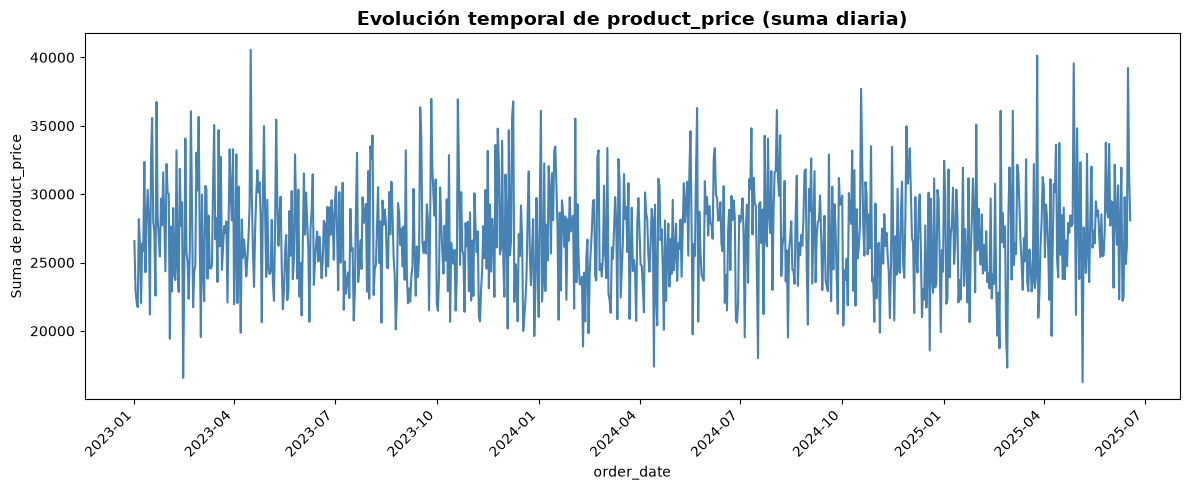

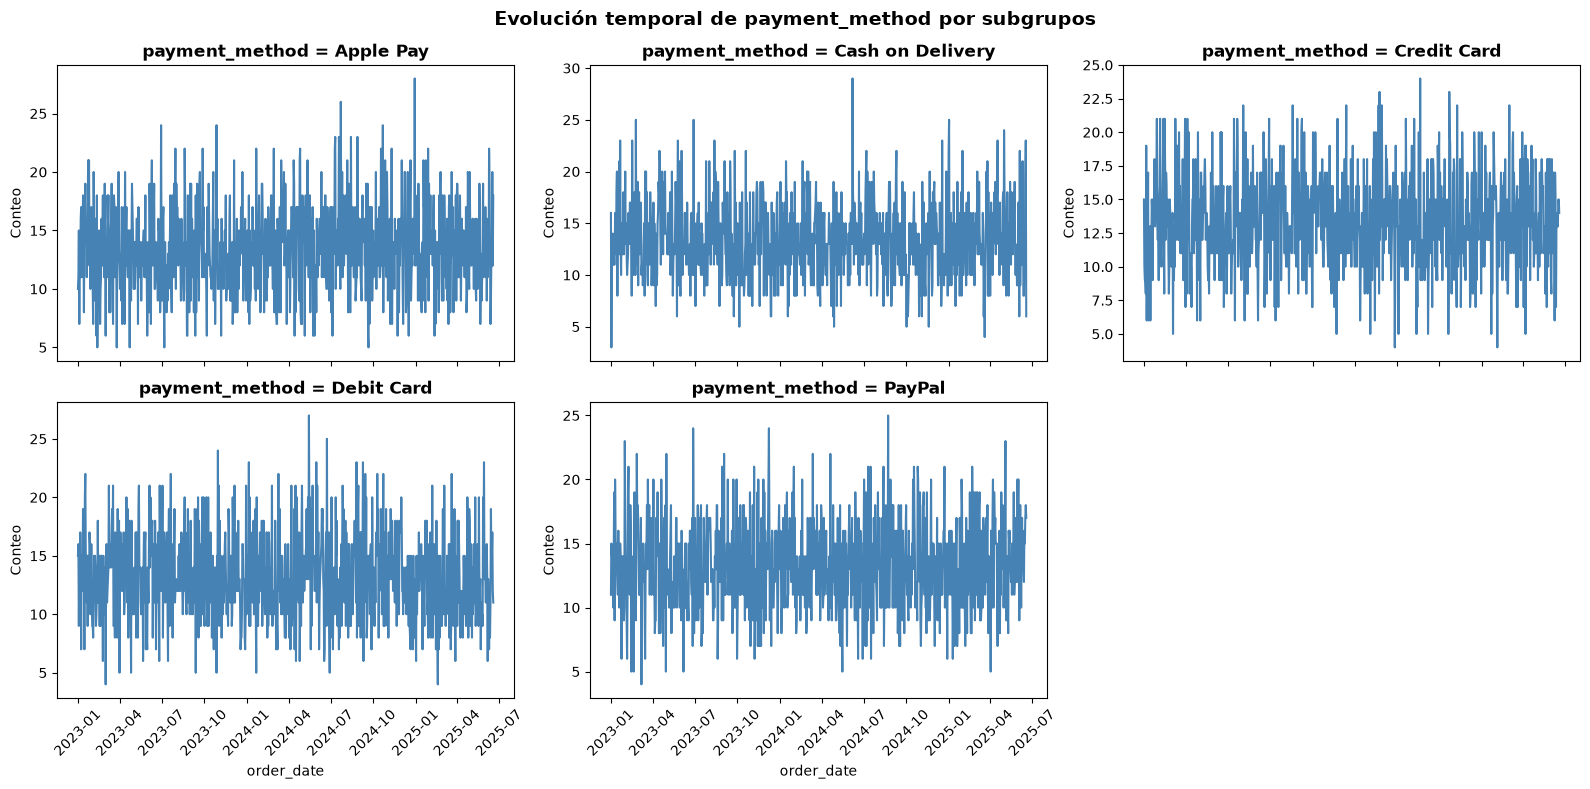

In [32]:
# Define aquí una variable numérica y una categórica para analizar su evolución temporal
columna_numerica = columns_numerical[0]
columna_categorica = 'payment_method'
columna_tiempo = 'order_date'

print(f'Variable numérica: {columna_numerica}')
print(f'Variable categórica: {columna_categorica}')
print(f'Variable temporal: {columna_tiempo}')

# Evolución temporal de la variable numérica: suma por fecha
serie_numerica = data.groupby(columna_tiempo)[columna_numerica].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=serie_numerica,
    x=columna_tiempo,
    y=columna_numerica,
    color='steelblue'
)
plt.title(f'Evolución temporal de {columna_numerica} (suma diaria)', fontsize=14, fontweight='bold')
plt.xlabel(columna_tiempo, fontsize=10)
plt.ylabel(f'Suma de {columna_numerica}', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Evolución temporal de la variable categórica: conteo por fecha y categoría
serie_categorica = (
    data.groupby([columna_tiempo, columna_categorica])
        .size()
        .reset_index(name='Conteo')
)

categorias = serie_categorica[columna_categorica].dropna().unique()
num_categorias = len(categorias)
num_columnas = 3
num_filas = (num_categorias + num_columnas - 1) // num_columnas

fig, axes = plt.subplots(num_filas, num_columnas, figsize=(16, 4 * num_filas), sharex=True, sharey=False)
axes = axes.flatten() if num_categorias > 1 else [axes]

for i, categoria in enumerate(categorias):
    subset = serie_categorica[serie_categorica[columna_categorica] == categoria]
    sns.lineplot(
        data=subset,
        x=columna_tiempo,
        y='Conteo',
        ax=axes[i],
        color='steelblue'
    )
    axes[i].set_title(f'{columna_categorica} = {categoria}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(columna_tiempo, fontsize=10)
    axes[i].set_ylabel('Conteo', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(num_categorias, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Evolución temporal de {columna_categorica} por subgrupos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()